In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('athletes.csv')
df.head(2)

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0


In [3]:
df.isna().sum()

id               0
name             0
nationality      0
sex              0
dob              1
height         330
weight         659
sport            0
gold             0
silver           0
bronze           0
dtype: int64

In [4]:
df.shape

(11538, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [6]:
df[df['weight'].isna()]

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
12,258556239,Abbas Qali,IOA,male,10/11/92,NaN,NaN,aquatics,0,0,0
28,349871091,Abdelhafid Benchabla,ALG,male,9/26/86,1.86,NaN,boxing,0,0,0
30,23564778,Abdelkader Chadi,ALG,male,12/12/86,1.78,NaN,boxing,0,0,0
37,934545704,Abdelrahman Salah Orabi Abdelgawwad,EGY,male,10/9/87,1.85,NaN,boxing,0,0,0
47,469953606,Abdoullah Bamoussa,ITA,male,6/8/86,NaN,NaN,athletics,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
11465,980866226,Zhaina Shekerbekova,KAZ,female,12/17/89,1.54,NaN,boxing,0,0,0
11468,405483135,Zhanibek Alimkhanuly,KAZ,male,4/1/93,1.82,NaN,boxing,0,0,0
11513,352983859,Zohir Kedache,ALG,male,3/2/86,1.78,NaN,boxing,0,0,0
11514,424586991,Zohra Ez Zahraoui,MAR,female,11/18/83,1.65,NaN,boxing,0,0,0


# 1
    a. проверьте наличие пропущенных значений. Преобразуйте/удалите пропуски по необходимости;
    b. закодируйте категориальные переменные числовыми значениями по необходимости.

    моя мысль изначальна была такая. разбить вес и рост на отрезки. И как то ориентироваться на них при заполнение пропусков. Ну не  может же атлет быть ростом 190 см. и быть весом 70. Тем более у мужчин и женщин разный вес рост.
    в общем я решил сгруппировать по полу и по спорту и уже там брать медиану

In [7]:
df.height.median()

1.76

In [8]:
df.weight.median()

70.0

In [9]:
df.groupby(['sex', 'sport'])['height'].median()

sex     sport            
female  aquatics             1.720
        archery              1.680
        athletics            1.690
        badminton            1.680
        basketball           1.850
        boxing               1.680
        canoe                1.700
        cycling              1.670
        equestrian           1.680
        fencing              1.715
        football             1.680
        golf                 1.680
        gymnastics           1.630
        handball             1.760
        hockey               1.670
        judo                 1.650
        modern pentathlon    1.690
        rowing               1.785
        rugby sevens         1.680
        sailing              1.700
        shooting             1.645
        table tennis         1.660
        taekwondo            1.730
        tennis               1.740
        triathlon            1.680
        volleyball           1.830
        weightlifting        1.600
        wrestling            

In [10]:
df['height'] = df.groupby(['sex', 'sport'])['height'].transform(lambda x: x.fillna(x.median()))

In [11]:
df['weight'] = df.groupby(['sex', 'sport'])['weight'].transform(lambda x: x.fillna(x.median()))

In [12]:
df.isna().sum()

id               0
name             0
nationality      0
sex              0
dob              1
height           0
weight         286
sport            0
gold             0
silver           0
bronze           0
dtype: int64

In [13]:
df['weight'] = df.groupby('sex')['weight'].transform(lambda x: x.fillna(x.median()))

In [14]:
df = df[df['dob'].notna()]


In [15]:
df 

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
11533,265605954,Zurian Hechavarria,CUB,female,8/10/95,1.64,58.0,athletics,0,0,0
11534,214461847,Zuzana Hejnova,CZE,female,12/19/86,1.73,63.0,athletics,0,0,0
11535,88361042,di Xiao,CHN,male,5/14/91,1.85,100.0,wrestling,0,0,0
11536,900065925,le Quoc Toan Tran,VIE,male,4/5/89,1.60,56.0,weightlifting,0,0,0


In [16]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})

In [17]:
df['sex'].value_counts()

sex
1    6332
0    5205
Name: count, dtype: int64

In [18]:
df = pd.get_dummies(df, columns=['sport'], drop_first=True)


In [19]:
df.head(2)

,id,name,nationality,sex,dob,height,weight,gold,silver,bronze,...,sport_rugby sevens,sport_sailing,sport_shooting,sport_table tennis,sport_taekwondo,sport_tennis,sport_triathlon,sport_volleyball,sport_weightlifting,sport_wrestling
0,736041664,A Jesus Garcia,ESP,1,10/17/69,1.72,64.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,532037425,A Lam Shin,KOR,0,9/23/86,1.68,56.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


# 2
    Разделите выборку на обучающее (80% данных) и тестовое (20% данных) подмножества.


In [20]:
from sklearn.model_selection import train_test_split

X = df[['height', 'weight'] + [col for col in df.columns if col.startswith('sport_')]]
y = df['sex']

In [21]:
X

,height,weight,sport_archery,sport_athletics,sport_badminton,sport_basketball,sport_boxing,sport_canoe,sport_cycling,sport_equestrian,...,sport_rugby sevens,sport_sailing,sport_shooting,sport_table tennis,sport_taekwondo,sport_tennis,sport_triathlon,sport_volleyball,sport_weightlifting,sport_wrestling
0,1.72,64.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.68,56.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.98,79.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.83,80.0,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1.81,71.0,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11533,1.64,58.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11534,1.73,63.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11535,1.85,100.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
11536,1.60,56.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


**stratify** что бы равномерно все делилось. что бы в тренировочных и тестовых соотношение мужчин и женщин было такое же как и в искодном датасете

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3 
    Постройте ROC-кривую с помощью функции roc_curve из библиотеки sklearn.metrics.


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
model.n_iter_


array([280], dtype=int32)

In [25]:
y_probs = model.predict_proba(X_test)[:, 1]
y_probs

array([0.05788724, 0.29185099, 0.05835532, ..., 0.47906451, 0.08960875,
       0.06209811])

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probs)


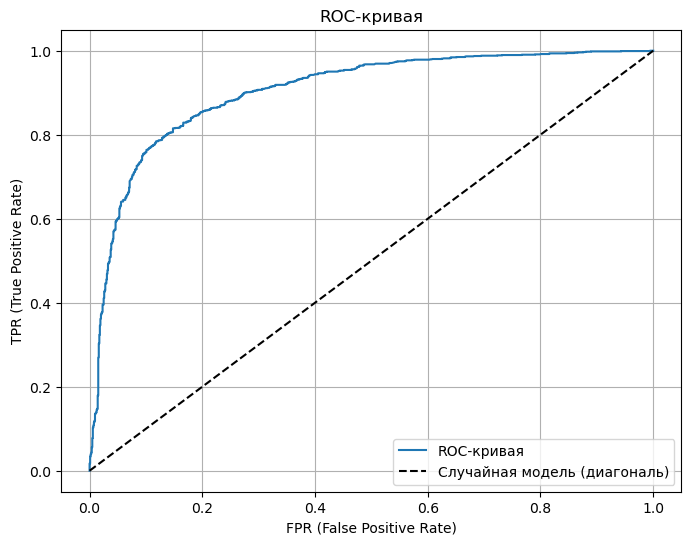

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC-кривая')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (диагональ)')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()


# 4
    Вычислите значение ROC-AUC метрики с помощью функции roc_auc_score из библиотеки sklearn.metrics.

In [28]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC: {roc_auc:.4f}")


ROC-AUC: 0.9034


# 5
    Реализуйте подсчет метрик TPR, FPR «вручную», без использования готовых функций из библиотеки sklearn.

In [29]:
import numpy as np

# пороги от 0 до 1
thresholds = np.linspace(0, 1, 100)

tpr_manual = []
fpr_manual = []

probs = model.predict_proba(X_test)[:, 1]

true_labels = y_test.values  

for thresh in thresholds:
    tp = fp = tn = fn = 0 # все по нулям

    for prob, actual in zip(probs, true_labels):
        predicted = 1 if prob >= thresh else 0 # М если больше порога и Ж если меньше

        if predicted == 1 and actual == 1:
            tp += 1
        elif predicted == 1 and actual == 0:
            fp += 1
        elif predicted == 0 and actual == 0:
            tn += 1
        elif predicted == 0 and actual == 1:
            fn += 1

    #  метрики
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tpr_manual.append(tpr)
    fpr_manual.append(fpr)



# 6
    Постройте ROC-кривую с помощью вычисленных в п. 5 метрик. Объедините графики из п. 3 и п. 6 в один. Сравните, сделайте вывод.

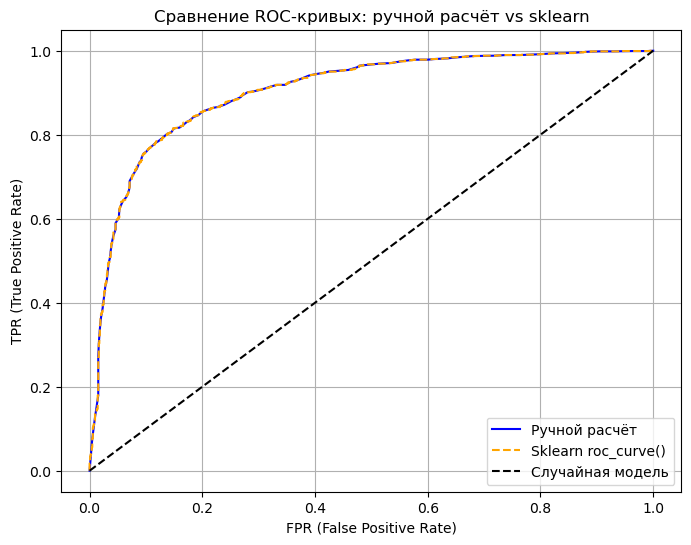

In [36]:
plt.figure(figsize=(8, 6))

# ручная 
plt.plot(fpr_manual, tpr_manual, label='Ручной расчёт', color='blue')

# sklearn
plt.plot(fpr, tpr, label='Sklearn roc_curve()', color='orange', linestyle='--')

# диагональ
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')

plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('Сравнение ROC-кривых: ручной расчёт vs sklearn')
plt.legend()
plt.grid(True)
plt.show()


# 7
    Постройте график Precision-Recall, используя метрики, посчитанные в п. 5.


In [45]:
precision_manual = []
recall_manual = []  # это то же самое, что TPR

for thresh in thresholds:
    tp = fp = tn = fn = 0
    for prob, actual in zip(probs, true_labels):
        predicted = 1 if prob >= thresh else 0

        if predicted == 1 and actual == 1:
            tp += 1
        elif predicted == 1 and actual == 0:
            fp += 1
        elif predicted == 0 and actual == 0:
            tn += 1
        elif predicted == 0 and actual == 1:
            fn += 1

    # recall — сколько мужчин нашли из всех настоящих
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # precision — насколько точно модель предсказывала мужчин (из всех, кого назвала мужчинами)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    recall_manual.append(recall)
    precision_manual.append(precision)


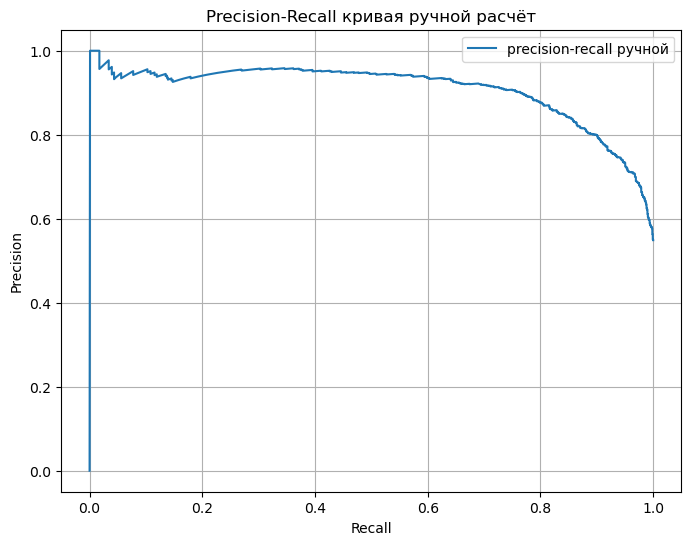

In [46]:
plt.figure(figsize=(8, 6))
plt.plot(recall_manual, precision_manual, label='precision-recall ручной')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая ручной расчёт')
plt.grid(True)
plt.legend()
plt.show()


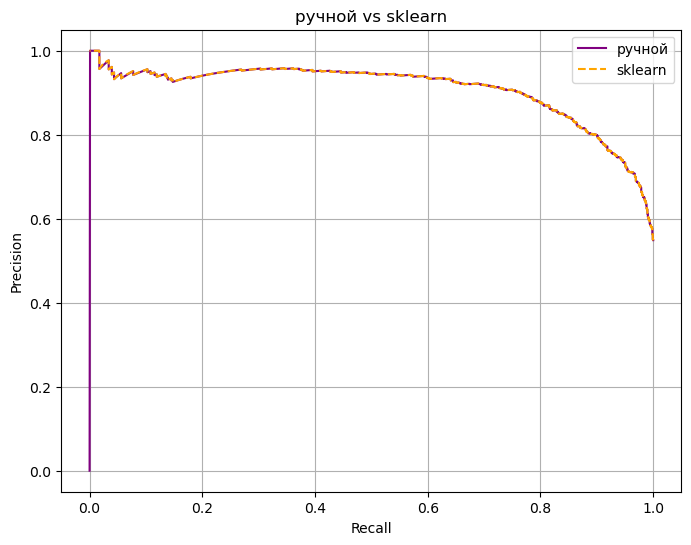

In [47]:
from sklearn.metrics import precision_recall_curve

precision_sk, recall_sk, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_manual, precision_manual, label='ручной', color='purple')
plt.plot(recall_sk, precision_sk, label='sklearn', color='orange', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('ручной vs sklearn')
plt.legend()
plt.grid(True)
plt.show()


# 8
    *Вычислите значение ROC-AUC метрики, используя метрики, посчитанные в п. 5.


In [51]:
auc_manual = 0

for i in range(len(fpr_manual) - 1):
    x1, x2 = fpr_manual[i], fpr_manual[i + 1]
    y1, y2 = tpr_manual[i], tpr_manual[i + 1]

    auc_manual += (x2 - x1) * (y1 + y2) / 2

print(f"Ручной ROC-AUC: {auc_manual:.4f}")


Ручной ROC-AUC (без trapz): -0.9034


    График с ROC-кривой.
    Чем ближе дуга к левому верхнему углу — тем лучше.
    По оси Y идёт TPR — это когда модель сказала "мужчина" и реально был мужчина.
    Значит, если кривая идёт вверх — модель отрабатывает нормально.
    По оси X у нас FPR — это когда модель сказала "мужчина", а на самом деле была женщина. То есть она ошиблась.
    Если кривая уходит вправо — значит модель чаще ошибается.
    Чем ближе она к левому краю — тем лучше.

    График Precision-Recall показывает, насколько точно модель угадывает "мужчина", и сколько мужчин она вообще находит.
    По оси X — Recall: это сколько мужчин из всех настоящих модель нашла.
    По оси Y — Precision: это насколько часто она была права, когда говорила "мужчина".
    В начале графика модель угадывает только самых уверенных — поэтому Precision = 1, но Recall маленький.
    Дальше модель начинает находить всё больше мужчин, но иногда ошибается — Precision немного падает.
    Под конец модель уже говорит "мужчина" почти всем, чтобы никого не пропустить — и Precision сильно падает.
    Чем кривая выше, тем лучше: это значит, что модель и много находит, и редко ошибается.



    По графикам видно, что модель работает хорошо.

    ROC-кривая поднимается близко к левому верхнему углу — это значит, что модель хорошо отличает мужчин от женщин и редко ошибается.
    AUC больше 0.9 — это тоже говорит о высоком качестве.

    Precision-Recall кривая тоже показывает, что при высоком Recall (модель находит много мужчин) Precision остаётся высоким (модель редко ошибается).
    То есть модель и находит нужный класс, и делает это точно.

    По этим метрикам можно сказать, что модель обучена хорошо.

# *может ли ROC-кривая проходить ниже диагонали?
    не может. скорее всего перепутали классы местами. Надо просто поменять их обратно — и кривая окажется выше.